## Imports

In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


### Downloading MNIST Data
##### Transforming pixel values in the range of [0, 1]

In [8]:
transform = transforms.ToTensor()  # gives values in [0,1]

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)

In [10]:
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
print("Train size:", len(train_dataset))

Train size: 60000


#### Model Architecture

In [9]:
class Autoencoder(nn.Module):
    def __init__(self, bottleneck=32, output_activation="sigmoid"):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(784, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, bottleneck)
        )

        self.decoder = nn.Sequential(
            nn.Linear(bottleneck, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 784)
        )

        if output_activation == "sigmoid":
            self.final_act = nn.Sigmoid()
        else:
            self.final_act = nn.Tanh()

    def forward(self, x):
        x = x.view(x.size(0), -1)
        z = self.encoder(x)
        x = self.decoder(z)
        x = self.final_act(x)
        return x

#### Training Code
##### Training the model for 30 epochs for each of the activations

In [11]:
def train_model(model, loader, epochs=30):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.MSELoss()

    losses = []

    for epoch in range(epochs):
        total_loss = 0

        for x, _ in loader:
            x = x.to(device)

            output = model(x)
            loss = criterion(output, x.view(x.size(0), -1))

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(loader)
        losses.append(avg_loss)
        print(f"Epoch {epoch+1}: Loss = {avg_loss:.4f}")

    return losses

In [12]:
# Sigmoid model
model_sigmoid = Autoencoder(output_activation="sigmoid")
loss_sigmoid = train_model(model_sigmoid, train_loader)

Epoch 1: Loss = 0.0589
Epoch 2: Loss = 0.0298
Epoch 3: Loss = 0.0237
Epoch 4: Loss = 0.0204
Epoch 5: Loss = 0.0183
Epoch 6: Loss = 0.0168
Epoch 7: Loss = 0.0155
Epoch 8: Loss = 0.0145
Epoch 9: Loss = 0.0137
Epoch 10: Loss = 0.0129
Epoch 11: Loss = 0.0124
Epoch 12: Loss = 0.0119
Epoch 13: Loss = 0.0115
Epoch 14: Loss = 0.0111
Epoch 15: Loss = 0.0108
Epoch 16: Loss = 0.0105
Epoch 17: Loss = 0.0102
Epoch 18: Loss = 0.0099
Epoch 19: Loss = 0.0097
Epoch 20: Loss = 0.0095
Epoch 21: Loss = 0.0093
Epoch 22: Loss = 0.0092
Epoch 23: Loss = 0.0090
Epoch 24: Loss = 0.0089
Epoch 25: Loss = 0.0087
Epoch 26: Loss = 0.0086
Epoch 27: Loss = 0.0084
Epoch 28: Loss = 0.0083
Epoch 29: Loss = 0.0082
Epoch 30: Loss = 0.0081


In [13]:
# Tanh model
model_tanh = Autoencoder(output_activation="tanh")
loss_tanh = train_model(model_tanh, train_loader)

Epoch 1: Loss = 0.0401
Epoch 2: Loss = 0.0248
Epoch 3: Loss = 0.0215
Epoch 4: Loss = 0.0199
Epoch 5: Loss = 0.0188
Epoch 6: Loss = 0.0180
Epoch 7: Loss = 0.0174
Epoch 8: Loss = 0.0169
Epoch 9: Loss = 0.0165
Epoch 10: Loss = 0.0161
Epoch 11: Loss = 0.0158
Epoch 12: Loss = 0.0155
Epoch 13: Loss = 0.0153
Epoch 14: Loss = 0.0150
Epoch 15: Loss = 0.0148
Epoch 16: Loss = 0.0145
Epoch 17: Loss = 0.0144
Epoch 18: Loss = 0.0142
Epoch 19: Loss = 0.0141
Epoch 20: Loss = 0.0139
Epoch 21: Loss = 0.0138
Epoch 22: Loss = 0.0137
Epoch 23: Loss = 0.0136
Epoch 24: Loss = 0.0135
Epoch 25: Loss = 0.0134
Epoch 26: Loss = 0.0133
Epoch 27: Loss = 0.0133
Epoch 28: Loss = 0.0132
Epoch 29: Loss = 0.0131
Epoch 30: Loss = 0.0131


#### Plotting the reconstruction loss for both TanH and Sigmoid Activation
##### It can be seen that sigmoid activation converges faster to a lower reconstruction loss

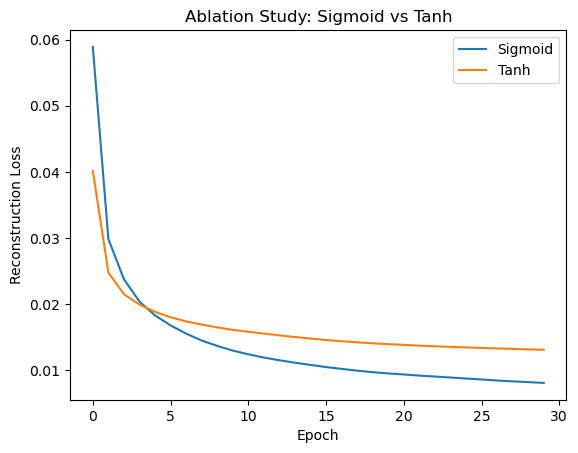

In [14]:
plt.plot(loss_sigmoid, label="Sigmoid")
plt.plot(loss_tanh, label="Tanh")
plt.xlabel("Epoch")
plt.ylabel("Reconstruction Loss")
plt.title("Ablation Study: Sigmoid vs Tanh")
plt.legend()
plt.show()

##### Reconstructing 10 Images from the dataset using both the models ( Sigmoid and TanH)

In [23]:
def show_reconstruction(model, loader):
    model.eval()
    with torch.no_grad():
        x, _ = next(iter(loader))
        x = x.to(device)

        recon = model(x)

        x = x.cpu().view(-1, 28, 28)
        recon = recon.cpu().view(-1, 28, 28)

        plt.figure(figsize=(20,4))

        for i in range(10):
            # Original
            plt.subplot(2,10,i+1)
            plt.imshow(x[i], cmap="gray")
            plt.axis("off")

            # Reconstructed
            plt.subplot(2,10,i+11)
            plt.imshow(recon[i], cmap="gray")
            plt.axis("off")

        plt.suptitle("Top: Original | Bottom: Reconstructed")
        plt.show()

#### Sigmoid
##### Reconstructed Images are almost indistinguishable from the real images

Sigmoid Results


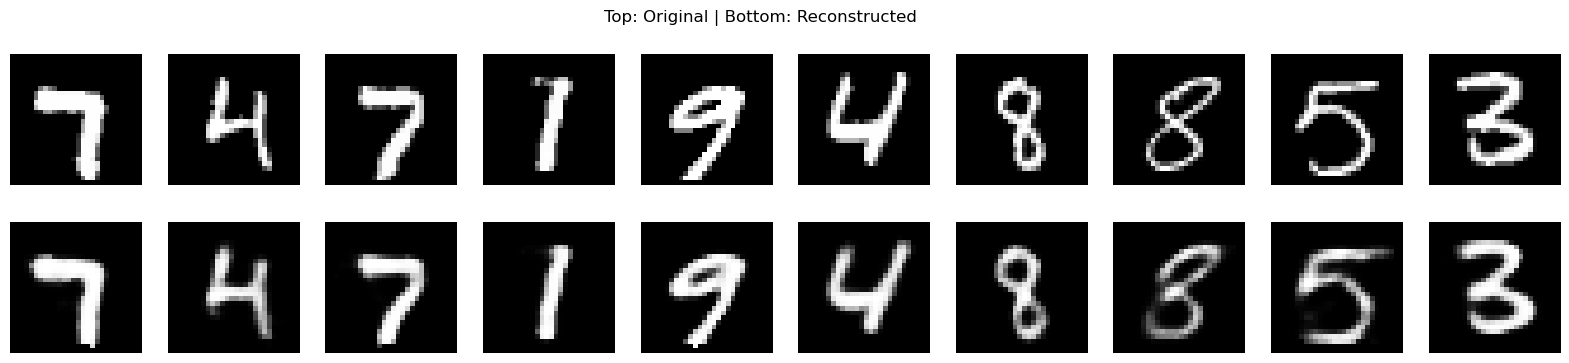

In [24]:
print("Sigmoid Results")
show_reconstruction(model_sigmoid, train_loader)

### TanH
##### Reconstructed images are distorted with blurry backgrounds ( due to [-1, 1] range of tanH)

Tanh Results


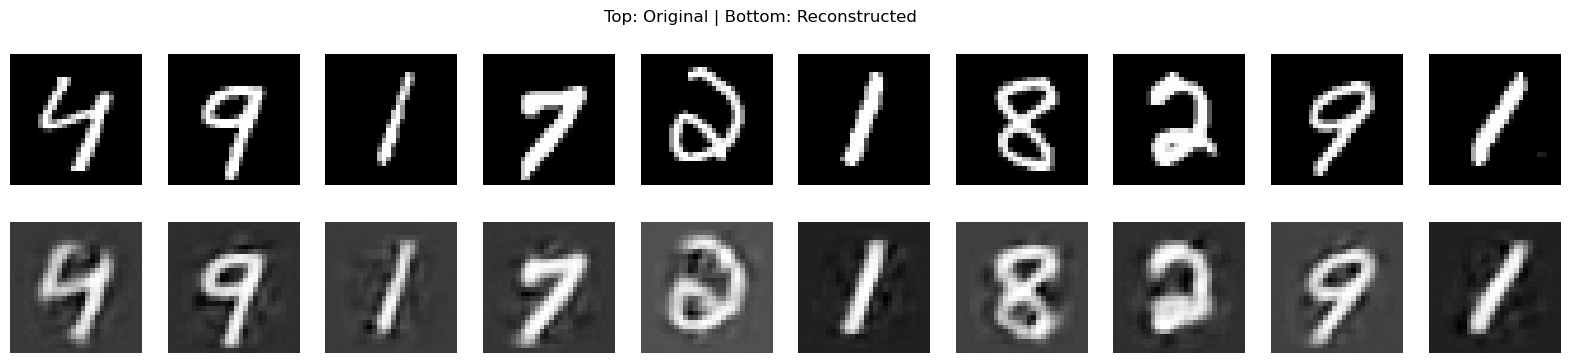

In [25]:
print("Tanh Results")
show_reconstruction(model_tanh, train_loader)